<a href="https://colab.research.google.com/github/farrelrassya/outlier-detection-python/blob/main/ch03_ml_based_outlier_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Machine Learning-Based Outlier Detection

*Outlier Detection in Python* -- Brett Kennedy (Manning, 2024)

---

This chapter marks the transition from univariate statistical tests (Chapter 2) to **multivariate machine learning methods** that consider all features simultaneously. These methods detect a much wider range of outliers -- including the subtle multivariate anomalies that univariate tests cannot catch.

We organize the landscape of outlier detection algorithms into broad categories: **distance-based**, **density-based**, **cluster-based**, **frequent item set-based**, and **model-based**. Before diving into these, we confront the **curse of dimensionality** -- the fundamental challenge that makes high-dimensional outlier detection so difficult.

**Key concepts in this chapter:**
- The curse of dimensionality: sparsity, margin effects, and distance concentration
- Distance-based detection (kthNN, KNN)
- Density-based detection (Radius, multidimensional KDE, LOF preview)
- Cluster-based detection (DBSCAN, HDBSCAN)
- Frequent item set-based detection (FPOF)
- Model-based detection (Real vs. Fake classifier)
- Properties of detectors: local vs. global, scores vs. flags, scalability, interpretability

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.neighbors import KernelDensity, BallTree
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import confusion_matrix
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print("Environment ready.")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")

Environment ready.
NumPy: 2.0.2
pandas: 2.2.2


We add `BallTree` for efficient nearest-neighbor queries, `DBSCAN` for cluster-based detection, `DecisionTreeClassifier` for the model-based approach, and `pdist`/`squareform` from SciPy for distance concentration experiments. The `breast_cancer` dataset from scikit-learn serves as our real-world testbed for the model-based detector.

## 3.1 The Curse of Dimensionality

Before examining specific algorithms, we must confront the most fundamental challenge in multivariate outlier detection: the **curse of dimensionality**. Working with large numbers of features introduces difficulties that simply do not exist in low dimensions. Many outlier detectors -- particularly those based on distances -- lose their effectiveness as the number of features grows, sometimes with as few as $10$--$20$ features.

The curse manifests in several ways, each of which we will demonstrate:
1. **Data sparsity**: the data space becomes astronomically large while the data remains finite
2. **Margin concentration**: almost all points end up near the edges of the data space
3. **Distance concentration**: all pairwise distances converge to roughly the same value
4. **Computational cost**: calculations become prohibitively slow

### 3.1.1 Data Sparsity

Consider a dataset with $10{,}000$ rows and $20$ categorical columns, each with $4$ distinct values. The number of possible combinations is $4^{20} = 1{,}099{,}511{,}627{,}776$ -- over **one trillion**. With only $10{,}000$ rows to fill this space, each combination has an expected frequency of $10{,}000 / 4^{20} \approx 9 \times 10^{-6}$. It is virtually guaranteed that every row is unique, and no combination occurs more than once. In such a sparse space, rarity carries no signal -- everything is rare.

Data sparsity with 10,000 rows, 4 categories per feature:
  d= 5:                     1,024 combinations, coverage = 9.77e+00
  d=10:                 1,048,576 combinations, coverage = 9.54e-03
  d=15:             1,073,741,824 combinations, coverage = 9.31e-06
  d=20:         1,099,511,627,776 combinations, coverage = 9.09e-09
  d=25:     1,125,899,906,842,624 combinations, coverage = 8.88e-12
  d=30: 1,152,921,504,606,846,976 combinations, coverage = 8.67e-15


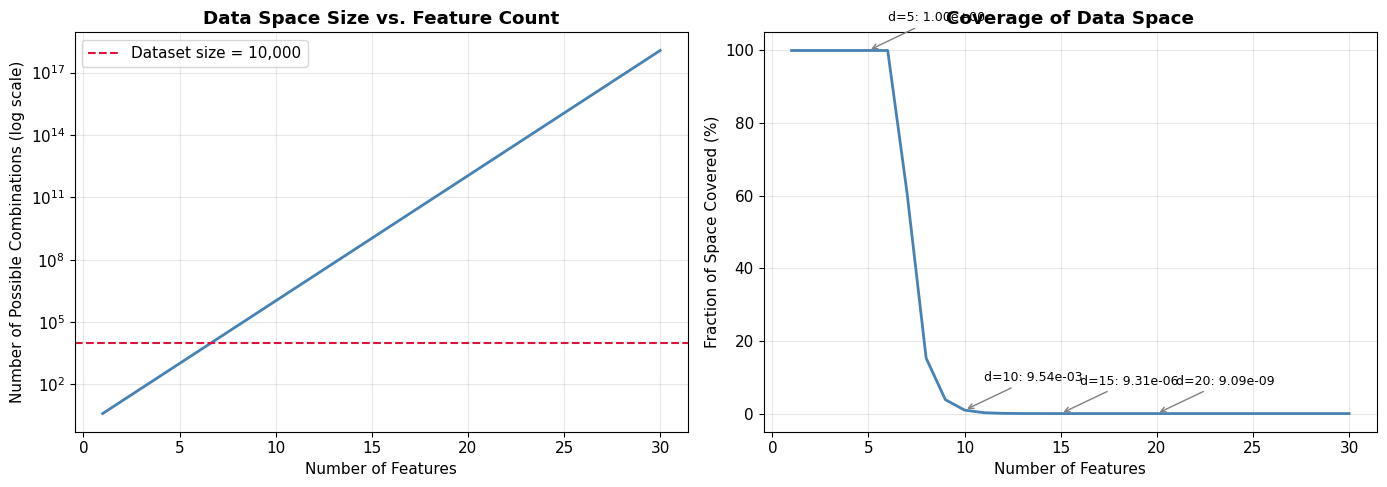

In [2]:
# Demonstrate data sparsity: fraction of space covered
dims = np.arange(1, 31)
n_rows = 10000
n_categories = 4

possible_combinations = n_categories ** dims
fraction_covered = np.minimum(n_rows / possible_combinations, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: possible combinations (log scale)
ax = axes[0]
ax.semilogy(dims, possible_combinations, 'steelblue', linewidth=2)
ax.axhline(n_rows, color='crimson', linestyle='--', linewidth=1.5, label=f'Dataset size = {n_rows:,}')
ax.set_xlabel('Number of Features')
ax.set_ylabel('Number of Possible Combinations (log scale)')
ax.set_title('Data Space Size vs. Feature Count', fontweight='bold')
ax.legend()

# Right: fraction of space covered
ax = axes[1]
ax.plot(dims, fraction_covered * 100, 'steelblue', linewidth=2)
ax.set_xlabel('Number of Features')
ax.set_ylabel('Fraction of Space Covered (%)')
ax.set_title('Coverage of Data Space', fontweight='bold')
ax.set_ylim(-5, 105)

# Annotate key points
for d in [5, 10, 15, 20]:
    frac = min(n_rows / (n_categories**d), 1.0)
    ax.annotate(f'd={d}: {frac:.2e}', xy=(d, frac*100), fontsize=9,
                xytext=(d+1, frac*100 + 8), arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()

print("Data sparsity with 10,000 rows, 4 categories per feature:")
for d in [5, 10, 15, 20, 25, 30]:
    combos = 4**d
    frac = n_rows / combos
    print(f"  d={d:2d}: {combos:>25,} combinations, coverage = {frac:.2e}")

The left panel shows the exponential explosion of the data space: with $20$ features, there are over $10^{12}$ possible combinations, dwarfing our $10{,}000$ rows. The right panel shows the fraction of this space we actually cover -- which drops to effectively zero beyond about $7$ features.

The implication is stark: **in high dimensions, every row is unique**. You cannot flag a combination as "rare" when *all* combinations are equally rare. Outlier detection methods that rely on counting combination frequencies (like the categorical methods from Chapter 2) become meaningless.

In practice, two factors mitigate this somewhat: (a) features are often **correlated**, so the data lives on a lower-dimensional manifold, and (b) values within features are **skewed**, so some regions are much more populated than others. But the fundamental challenge remains -- and it grows worse with every additional feature.

### 3.1.2 Margin Concentration

A second unintuitive effect: in high dimensions, almost all data points end up near the **margins** (edges) of the data space, even if each individual feature is centered. If $90\%$ of data in each dimension is "central," the probability of being central in *all* $d$ dimensions is $0.9^d$.

With 90% central per dimension:
  d=7: 52.2% on margin
  d=22: 90.2% on margin
  d=44: 99.0% on margin
  d=20: 87.8% on margin
  d=40: 98.5% on margin


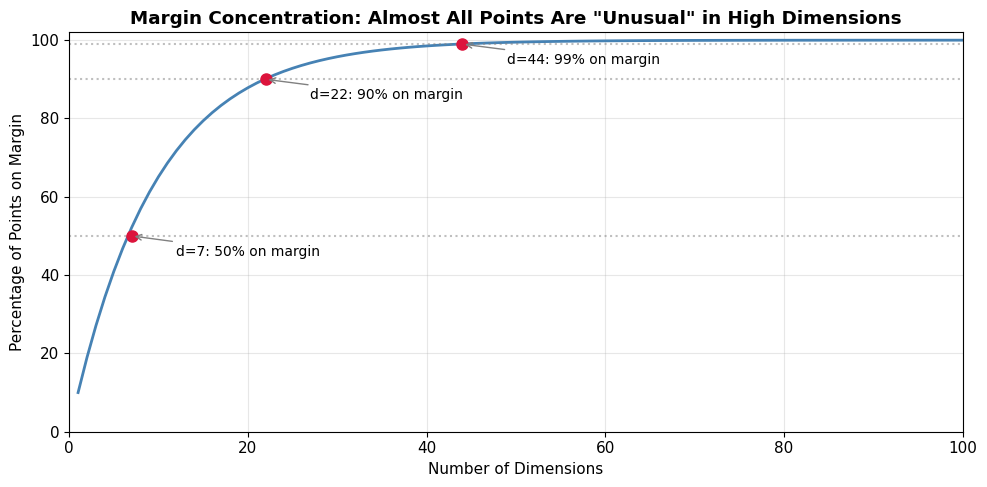

In [3]:
# Demonstrate margin concentration
dims = np.arange(1, 101)
central_prob_per_dim = 0.9
prob_all_central = central_prob_per_dim ** dims
prob_on_margin = 1 - prob_all_central

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dims, prob_on_margin * 100, 'steelblue', linewidth=2)
ax.axhline(50, color='gray', linestyle=':', alpha=0.5)
ax.axhline(90, color='gray', linestyle=':', alpha=0.5)
ax.axhline(99, color='gray', linestyle=':', alpha=0.5)

# Annotate key thresholds
d_50 = np.argmax(prob_on_margin > 0.5) + 1
d_90 = np.argmax(prob_on_margin > 0.9) + 1
d_99 = np.argmax(prob_on_margin > 0.99) + 1
ax.plot(d_50, 50, 'o', color='crimson', markersize=8)
ax.plot(d_90, 90, 'o', color='crimson', markersize=8)
ax.plot(d_99, 99, 'o', color='crimson', markersize=8)
ax.annotate(f'd={d_50}: 50% on margin', xy=(d_50, 50), xytext=(d_50+5, 45), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate(f'd={d_90}: 90% on margin', xy=(d_90, 90), xytext=(d_90+5, 85), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate(f'd={d_99}: 99% on margin', xy=(d_99, 99), xytext=(d_99+5, 94), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Number of Dimensions')
ax.set_ylabel('Percentage of Points on Margin')
ax.set_title('Margin Concentration: Almost All Points Are "Unusual" in High Dimensions', fontweight='bold')
ax.set_xlim(0, 100)
ax.set_ylim(0, 102)

plt.tight_layout()
print(f"With 90% central per dimension:")
print(f"  d={d_50}: {prob_on_margin[d_50-1]*100:.1f}% on margin")
print(f"  d={d_90}: {prob_on_margin[d_90-1]*100:.1f}% on margin")
print(f"  d={d_99}: {prob_on_margin[d_99-1]*100:.1f}% on margin")
print(f"  d=20: {prob_on_margin[19]*100:.1f}% on margin")
print(f"  d=40: {prob_on_margin[39]*100:.1f}% on margin")

With just $20$ dimensions, about $88\%$ of data points are "marginal" -- unusual in at least one dimension -- even though $90\%$ of values are central in each individual dimension. By $d = 44$, over $99\%$ of points are on the margin.

The implication for outlier detection: **in high dimensions, being unusual in some dimension is the norm, not the exception**. Any method that flags points for being marginal in *any* dimension will flag almost everything. Effective high-dimensional outlier detection must be more selective -- looking for points that are unusual in *many* dimensions simultaneously or unusual in specific, meaningful combinations.

### 3.1.3 Distance Concentration

The most damaging effect for distance-based outlier detectors: as dimensionality increases, **all pairwise distances converge to roughly the same value**. The relative difference between the nearest and farthest neighbor shrinks toward zero:

$$\frac{d_{\max} - d_{\min}}{d_{\min}} \to 0 \quad \text{as } p \to \infty$$

This means distance-based methods cannot distinguish outliers from inliers -- every point is approximately equidistant from every other point.

Distance concentration (relative contrast):
  d=  2: (max-min)/min = 497.299
  d=  5: (max-min)/min = 18.519
  d= 10: (max-min)/min = 5.442
  d= 20: (max-min)/min = 2.604
  d= 50: (max-min)/min = 1.444
  d=100: (max-min)/min = 0.848
  d=200: (max-min)/min = 0.486
  d=500: (max-min)/min = 0.295


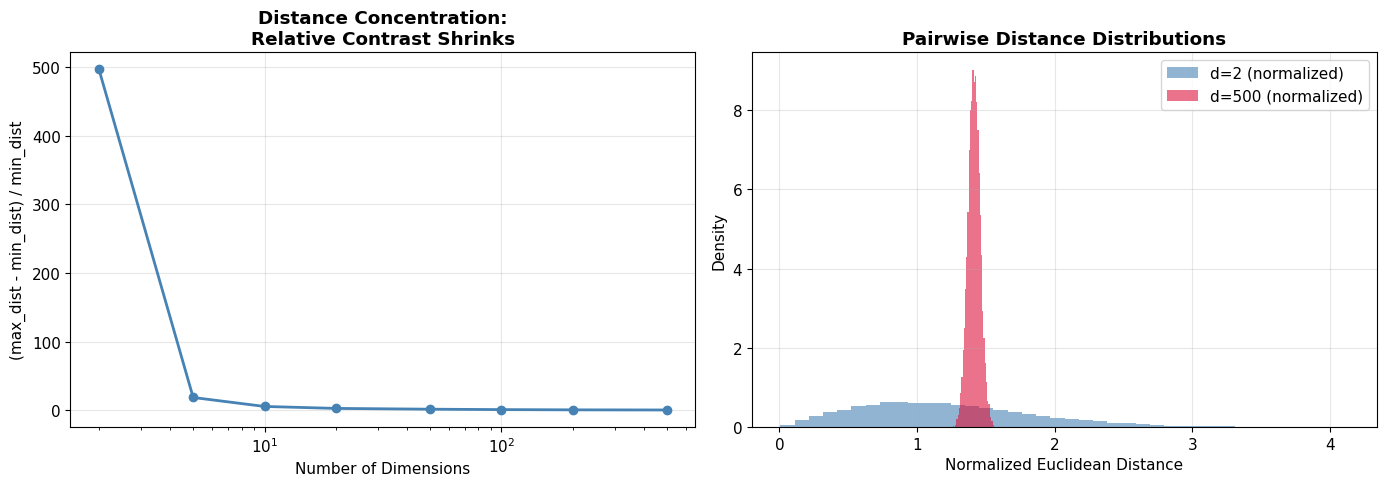

In [4]:
# Demonstrate distance concentration
np.random.seed(42)
n_points = 200
dimensions = [2, 5, 10, 20, 50, 100, 200, 500]

ratios = []
for d in dimensions:
    X = np.random.normal(0, 1, (n_points, d))
    dists = pdist(X, metric='euclidean')
    ratio = (dists.max() - dists.min()) / dists.min()
    ratios.append(ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: relative contrast
ax = axes[0]
ax.plot(dimensions, ratios, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.set_xlabel('Number of Dimensions')
ax.set_ylabel('(max_dist - min_dist) / min_dist')
ax.set_title('Distance Concentration:\nRelative Contrast Shrinks', fontweight='bold')
ax.set_xscale('log')

# Right: histogram of pairwise distances at d=2 vs d=500
ax = axes[1]
X_2d = np.random.normal(0, 1, (n_points, 2))
X_500d = np.random.normal(0, 1, (n_points, 500))
dists_2d = pdist(X_2d) / np.sqrt(2)       # normalize by sqrt(d)
dists_500d = pdist(X_500d) / np.sqrt(500)

ax.hist(dists_2d, bins=40, alpha=0.6, color='steelblue', density=True, label='d=2 (normalized)')
ax.hist(dists_500d, bins=40, alpha=0.6, color='crimson', density=True, label='d=500 (normalized)')
ax.set_xlabel('Normalized Euclidean Distance')
ax.set_ylabel('Density')
ax.set_title('Pairwise Distance Distributions', fontweight='bold')
ax.legend()

plt.tight_layout()

print("Distance concentration (relative contrast):")
for d, r in zip(dimensions, ratios):
    print(f"  d={d:>3d}: (max-min)/min = {r:.3f}")

**Left panel**: The relative contrast between the farthest and nearest pairwise distances drops dramatically as dimensionality increases. At $d = 2$, the contrast ratio is large -- distances vary widely, and outliers stand out clearly. By $d = 500$, the ratio is small -- all distances are nearly identical.

**Right panel**: The normalized distance distributions tell the story visually. At $d = 2$, pairwise distances spread over a wide range (broad blue histogram). At $d = 500$, they concentrate into a narrow peak (tight red histogram). When all distances are the same, a kthNN detector cannot distinguish an outlier from an inlier -- both have the same distance to their neighbors.

Mathematically, this happens because each dimension contributes independently to the Euclidean distance:

$$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{j=1}^{p} (x_j - y_j)^2}$$

By the law of large numbers, as $p$ grows, this sum converges to its expected value for *all* pairs of points, erasing the differences between them. This is why the book emphasizes: **detectors dependent on distance calculations can become unusable with large numbers of features, unless features are removed or dimensionality reduction is performed**.

## 3.2 Types of Algorithms

Machine learning outlier detection algorithms fall into several broad categories. Understanding these categories helps us select appropriate detectors for different data characteristics and predict their strengths and weaknesses.

**Important prerequisites for most multivariate detectors:**
1. All features must be **numeric** (categorical features need encoding)
2. Numeric features must be **scaled** to the same range (usually min-max or z-score standardization)
3. Missing values must be handled

We now examine each category with working code examples.

### 3.2.1 Distance-Based: kthNN

Distance-based algorithms flag records that have **few nearby neighbors**. The most widely used is **kthNN** (k-th nearest neighbors): for each point, compute the distance to its $k$th nearest neighbor. Points with large distances are outliers.

A variation, **KNN** (averaging distances to all $k$ nearest neighbors), is more robust because it is less sensitive to the exact value of $k$.

Figure 3.2: KNN outlier detection (k=3) on synthetic 2-cluster data.
  Total points: 1000
  Score range: [0.0139, 2.0098]
  Mean score: 0.1073
  Top 5 scores: [2.0098105643581947, 1.469548851489714, 1.378324223473151, 1.307993039226328, 1.2591360602832038]


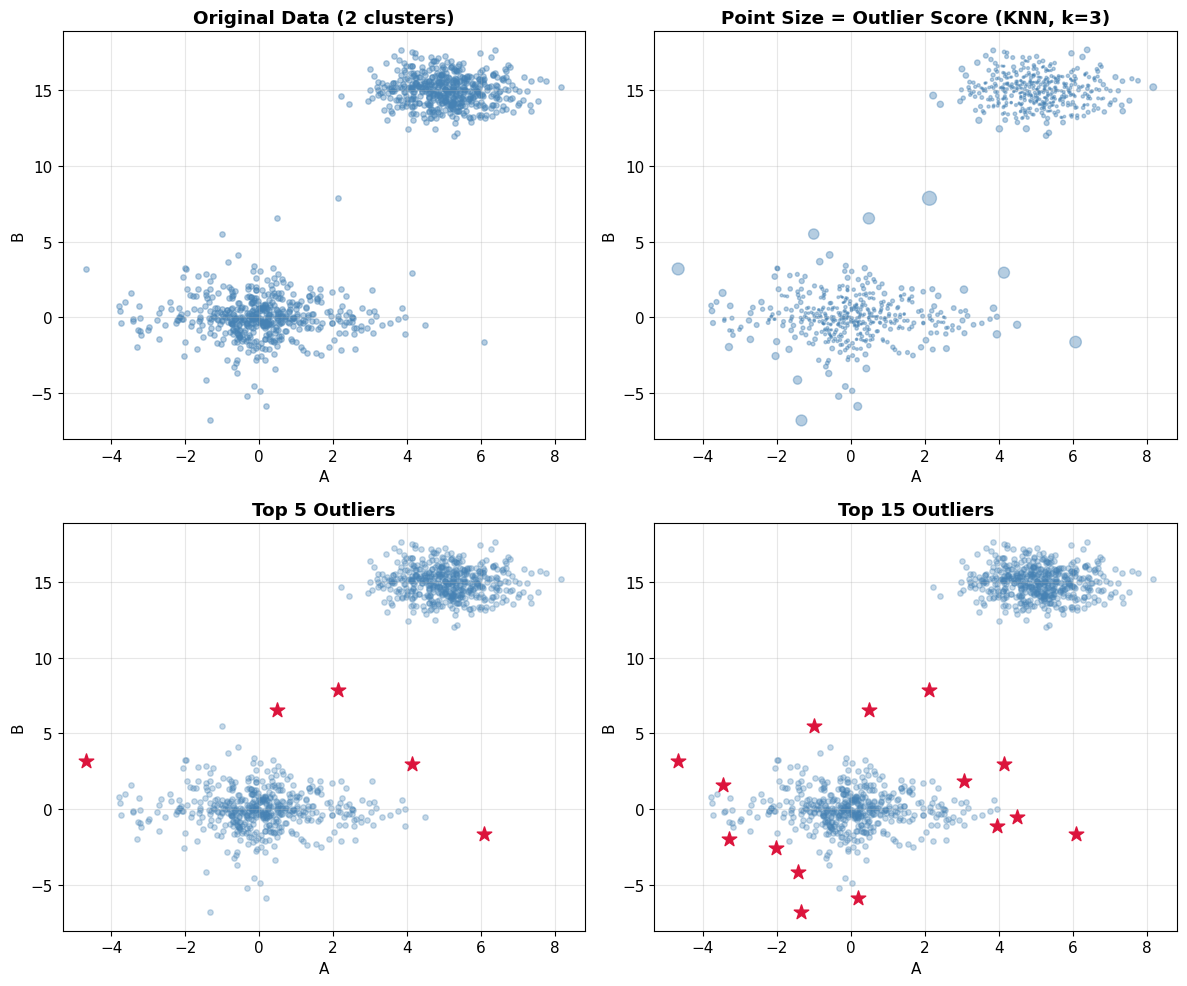

In [5]:
# Listing 3.1: KNN outlier detector on synthetic data
np.random.seed(0)
n_per_cluster = 500

# Cluster 1: Laplace (heavier tails than Gaussian)
data_a = np.random.laplace(size=n_per_cluster)
data_b = np.random.laplace(size=n_per_cluster)
df1 = pd.DataFrame({"A": data_a, "B": data_b})

# Cluster 2: Gaussian, offset
data_a = np.random.normal(loc=5, size=n_per_cluster)
data_b = np.random.normal(loc=15, size=n_per_cluster)
df2 = pd.DataFrame({"A": data_a, "B": data_b})

df = pd.concat([df1, df2], ignore_index=True)

# Build BallTree and compute KNN scores (k=3)
tree = BallTree(df[['A', 'B']], leaf_size=100)
dist, _ = tree.query(df[['A', 'B']], k=3)
df['Score'] = [x.mean() for x in dist]  # average distance to 3 nearest

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top left: raw data
ax = axes[0, 0]
ax.scatter(df['A'], df['B'], alpha=0.4, c='steelblue', s=15)
ax.set_title('Original Data (2 clusters)', fontweight='bold')
ax.set_xlabel('A'); ax.set_ylabel('B')

# Top right: sized by score
ax = axes[0, 1]
ax.scatter(df['A'], df['B'], s=50*df['Score'], alpha=0.4, c='steelblue')
ax.set_title('Point Size = Outlier Score (KNN, k=3)', fontweight='bold')
ax.set_xlabel('A'); ax.set_ylabel('B')

# Bottom left: top 5
cutoff_5 = sorted(df['Score'])[-6]
outliers_5 = df['Score'] > cutoff_5
ax = axes[1, 0]
ax.scatter(df.loc[~outliers_5, 'A'], df.loc[~outliers_5, 'B'], alpha=0.3, c='steelblue', s=15)
ax.scatter(df.loc[outliers_5, 'A'], df.loc[outliers_5, 'B'], c='crimson', s=120, marker='*', zorder=5)
ax.set_title(f'Top 5 Outliers', fontweight='bold')
ax.set_xlabel('A'); ax.set_ylabel('B')

# Bottom right: top 15
cutoff_15 = sorted(df['Score'])[-16]
outliers_15 = df['Score'] > cutoff_15
ax = axes[1, 1]
ax.scatter(df.loc[~outliers_15, 'A'], df.loc[~outliers_15, 'B'], alpha=0.3, c='steelblue', s=15)
ax.scatter(df.loc[outliers_15, 'A'], df.loc[outliers_15, 'B'], c='crimson', s=120, marker='*', zorder=5)
ax.set_title(f'Top 15 Outliers', fontweight='bold')
ax.set_xlabel('A'); ax.set_ylabel('B')

plt.tight_layout()

print(f"Figure 3.2: KNN outlier detection (k=3) on synthetic 2-cluster data.")
print(f"  Total points: {len(df)}")
print(f"  Score range: [{df['Score'].min():.4f}, {df['Score'].max():.4f}]")
print(f"  Mean score: {df['Score'].mean():.4f}")
print(f"  Top 5 scores: {sorted(df['Score'])[-5:][::-1]}")

This recreates the book's Figure 3.2. The four panels show the complete KNN workflow:

**Top-left**: Raw data with two clusters. Cluster 1 (centered at origin) follows a **Laplace distribution**, which has heavier tails than Gaussian -- meaning more natural outliers. Cluster 2 (centered at $(5, 15)$) follows a Gaussian distribution.

**Top-right**: Each point's size is proportional to its KNN outlier score (average distance to $k=3$ nearest neighbors). Points on the fringes of clusters have large markers because their nearest neighbors are relatively far away.

**Bottom-left / Bottom-right**: Binary outlier labels for the top $5$ and top $15$ scores. The flagged points (red stars) sit at the fringes of Cluster 1, which makes sense: Cluster 1 has heavier tails (Laplace), so its fringe points are more isolated than Cluster 2's fringe points.

The Euclidean distance between two records $\mathbf{x}$ and $\mathbf{x}'$ across $p$ features is:

$$d(\mathbf{x}, \mathbf{x}') = \sqrt{\sum_{j=1}^{p} (x_j - x_j')^2}$$

**Why $k$ should stay small.** Setting $k = N$ (all points) averages over so many distances that all scores converge to similar values -- the same distance concentration problem we saw with high dimensions. In practice, $k$ between $2$ and $50$ works best, with larger datasets tolerating larger $k$. Using $k=3$ here works well because even small isolated clusters (of $1$--$2$ points) produce high scores.

### 3.2.2 Density-Based: Radius

Density-based methods estimate the **local density** around each point and flag those in low-density regions. The **Radius** method counts how many points fall within a fixed radius $r$ of each point. Points with few neighbors within the radius are in sparse regions and receive high outlier scores.

This is analogous to KNN but inverts the question: instead of "how far to my $k$th neighbor?" (distance-based), we ask "how many neighbors within distance $r$?" (density-based).

Figure 3.3: Radius-based outlier detection (r=2.0).
  Neighbor counts: min=1, max=445, median=304
  Points with 0 neighbors: 1


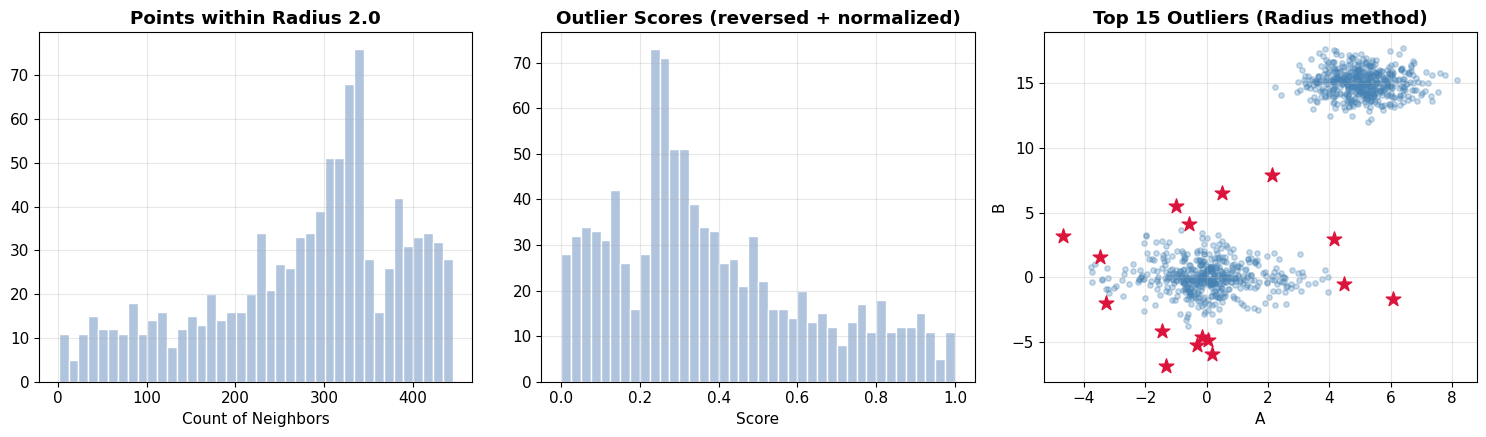

In [6]:
# Listing 3.2: Radius outlier detection
np.random.seed(0)
n_per_cluster = 500
df1 = pd.DataFrame({"A": np.random.laplace(size=n_per_cluster), "B": np.random.laplace(size=n_per_cluster)})
df2 = pd.DataFrame({"A": np.random.normal(loc=5, size=n_per_cluster), "B": np.random.normal(loc=15, size=n_per_cluster)})
df_r = pd.concat([df1, df2], ignore_index=True)

tree = BallTree(df_r[['A', 'B']])
counts = tree.query_radius(df_r[['A', 'B']], 2.0, count_only=True)

# Convert counts to outlier scores (fewer neighbors = higher score)
min_c, max_c = min(counts), max(counts)
scores = [(max_c - x) / (max_c - min_c) for x in counts]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Count distribution
ax = axes[0]
ax.hist(counts, bins=40, color='lightsteelblue', edgecolor='white')
ax.set_title('Points within Radius 2.0', fontweight='bold')
ax.set_xlabel('Count of Neighbors')

# Score distribution
ax = axes[1]
ax.hist(scores, bins=40, color='lightsteelblue', edgecolor='white')
ax.set_title('Outlier Scores (reversed + normalized)', fontweight='bold')
ax.set_xlabel('Score')

# Flagged outliers
threshold = sorted(scores, reverse=True)[15]
df_r['Score'] = scores
flagged = df_r['Score'] >= threshold
ax = axes[2]
ax.scatter(df_r.loc[~flagged, 'A'], df_r.loc[~flagged, 'B'], alpha=0.3, c='steelblue', s=15)
ax.scatter(df_r.loc[flagged, 'A'], df_r.loc[flagged, 'B'], c='crimson', s=120, marker='*', zorder=5)
ax.set_title('Top 15 Outliers (Radius method)', fontweight='bold')
ax.set_xlabel('A'); ax.set_ylabel('B')

plt.tight_layout()
print(f"Figure 3.3: Radius-based outlier detection (r=2.0).")
print(f"  Neighbor counts: min={min_c}, max={max_c}, median={np.median(counts):.0f}")
print(f"  Points with 0 neighbors: {(counts == 1).sum()}")

This recreates the book's Figure 3.3. The workflow mirrors KNN but with an inverted perspective:

**Left -- Neighbor counts.** Most points have many neighbors within radius $2.0$ (high counts = dense regions). A small tail of points has few neighbors (low counts = sparse regions).

**Center -- Outlier scores.** We reverse and normalize the counts so that high scores correspond to sparse regions. The distribution is heavily right-skewed -- most points are normal, with a small tail of outliers.

**Right -- Flagged outliers.** The top $15$ scores produce a set of outliers at the fringes of both clusters, similar to the KNN results.

**Radius vs. KNN tradeoffs:**
- **KNN** requires choosing $k$ (number of neighbors), which is relatively intuitive
- **Radius** requires choosing $r$ (distance threshold), which is much less intuitive and must be found experimentally
- Radius can be more stable because it captures the actual density, not just an ordinal ranking of distances
- But Radius is more sensitive to the choice of $r$: too small flags everything, too large flags nothing

In practice, KNN is more commonly used because $k$ is easier to set, but Radius has theoretical appeal for density estimation.

### 3.2.2 (cont.) Density-Based: Multidimensional KDE

KDE extends naturally from $1$D (Chapter 2) to any number of dimensions. In $2$D, we place a $3$D Gaussian bump at each data point and sum them, creating a continuous density surface. Points in low-density regions receive high outlier scores.

Figure 3.4: 2D KDE density plot (left) and top 30 outliers (right).
  Log-density range: [-6.80, -1.76]
  Top 30 threshold: score > 4.13


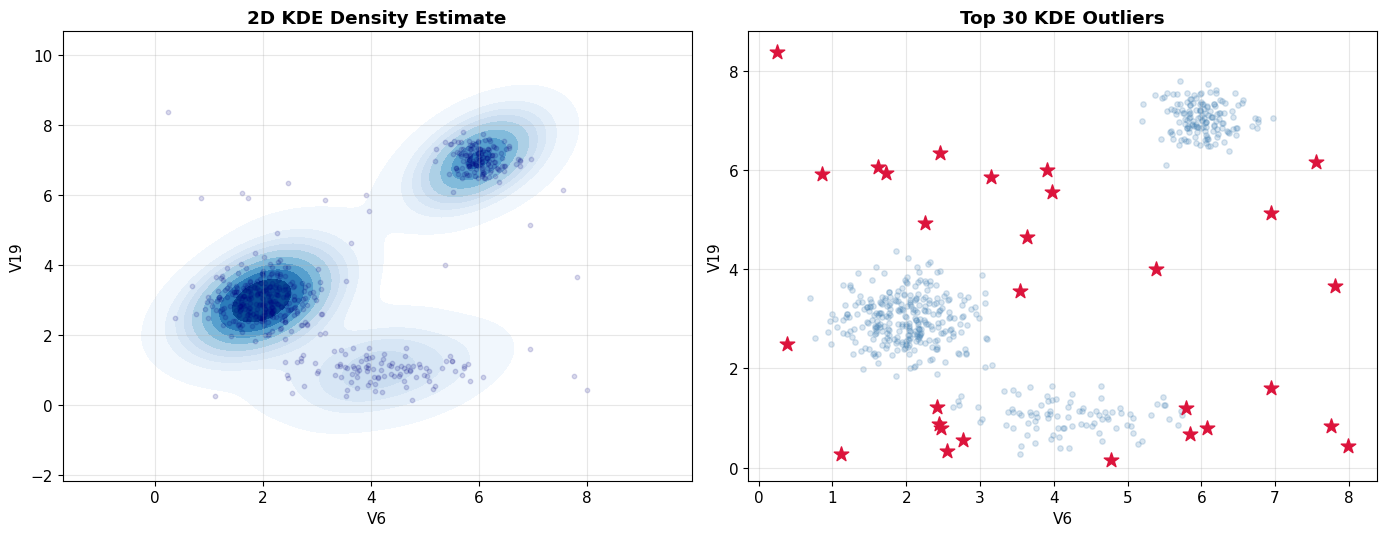

In [7]:
# Multidimensional KDE on synthetic data similar to wall-robot-navigation
np.random.seed(42)

# Create data with 3 clusters of different densities
c1 = np.random.normal([2, 3], [0.5, 0.5], (300, 2))
c2 = np.random.normal([6, 7], [0.3, 0.3], (150, 2))
c3 = np.random.normal([4, 1], [1.0, 0.3], (100, 2))
noise = np.random.uniform([0, 0], [8, 9], (20, 2))
X_kde2d = np.vstack([c1, c2, c3, noise])
data_df_kde = pd.DataFrame(X_kde2d, columns=['V6', 'V19'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: KDE density plot
ax = axes[0]
sns.kdeplot(data=data_df_kde, x='V6', y='V19', fill=True, cmap='Blues', ax=ax)
ax.scatter(data_df_kde['V6'], data_df_kde['V19'], alpha=0.15, s=10, c='navy')
ax.set_title('2D KDE Density Estimate', fontweight='bold')

# Right: KDE-based outlier detection
kde = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(X_kde2d)
log_density = kde.score_samples(X_kde2d)
data_df_kde['KDE_Score'] = -log_density  # negate: low density = high score

cutoff_kde = sorted(data_df_kde['KDE_Score'])[-30]
data_df_kde['Outlier'] = data_df_kde['KDE_Score'] > cutoff_kde

ax = axes[1]
ax.scatter(data_df_kde.loc[~data_df_kde['Outlier'], 'V6'],
           data_df_kde.loc[~data_df_kde['Outlier'], 'V19'],
           alpha=0.2, s=15, c='steelblue')
ax.scatter(data_df_kde.loc[data_df_kde['Outlier'], 'V6'],
           data_df_kde.loc[data_df_kde['Outlier'], 'V19'],
           s=120, marker='*', c='crimson', zorder=5)
ax.set_title(f'Top 30 KDE Outliers', fontweight='bold')
ax.set_xlabel('V6'); ax.set_ylabel('V19')

plt.tight_layout()

print(f"Figure 3.4: 2D KDE density plot (left) and top 30 outliers (right).")
print(f"  Log-density range: [{log_density.min():.2f}, {log_density.max():.2f}]")
print(f"  Top 30 threshold: score > {cutoff_kde:.2f}")

This recreates the book's Figure 3.4. The left panel shows the **KDE density surface** as a filled contour plot with data points overlaid. Dense regions appear as dark blue concentrated areas; sparse regions are light. The right panel flags the top $30$ outliers (red stars), which cluster in the low-density regions between and around the main clusters.

KDE uses scikit-learn's `KernelDensity` with a Gaussian kernel. The `score_samples()` method returns log-density values -- we negate these so that **low density = high outlier score**. The bandwidth parameter ($h = 0.5$ here) controls smoothness, exactly as in the $1$D case from Chapter 2.

KDE is a **global density** detector: it computes an absolute density at each point and compares it to all other densities. This means it may miss **local outliers** in a dense cluster -- a point that is unusual for its cluster but still in a reasonably dense region overall. For local outlier detection, we need methods like **LOF** (Local Outlier Factor), which we preview later and cover in depth in subsequent chapters.

### 3.2.3 Cluster-Based: DBSCAN

Cluster-based outlier detection exploits the correspondence between clustering and outlier detection: **inliers are near cluster centers; outliers are far from all clusters**. DBSCAN is particularly well-suited because it naturally identifies points that don't belong to any cluster (label $= -1$).

DBSCAN has two parameters:
- `eps`: the maximum distance between two samples to be considered neighbors
- `min_samples`: the minimum number of points to form a dense region (core point)

Points that are not reachable from any core point are labeled as **noise** -- our outlier candidates.

Figure 3.6: DBSCAN-based outlier detection.
  Clusters found: 3
  Points in clusters: 389
  Noise points (outliers): 16


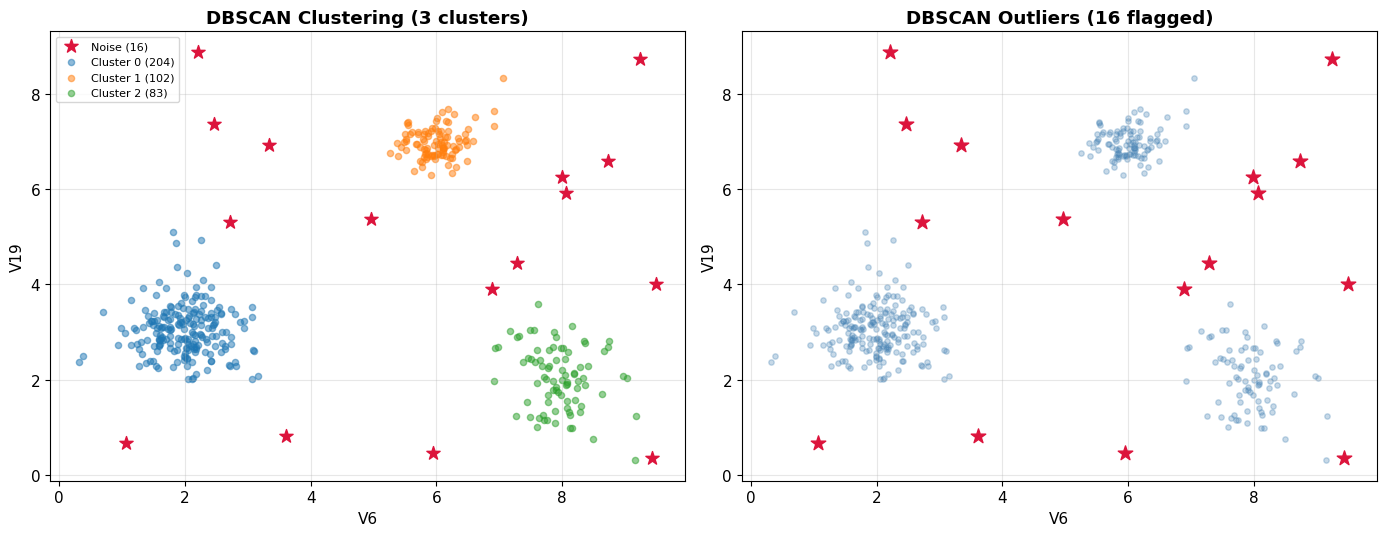

In [8]:
# Listing 3.5: DBSCAN-based outlier detection
np.random.seed(42)

# Synthetic data with 3 clusters + scattered noise
c1 = np.random.normal([2, 3], [0.5, 0.5], (200, 2))
c2 = np.random.normal([6, 7], [0.3, 0.3], (100, 2))
c3 = np.random.normal([8, 2], [0.4, 0.6], (80, 2))
noise_pts = np.random.uniform([0, 0], [10, 9], (25, 2))
X_db = np.vstack([c1, c2, c3, noise_pts])
df_db = pd.DataFrame(X_db, columns=['V6', 'V19'])

clustering = DBSCAN(eps=0.8, min_samples=10).fit_predict(X_db)
df_db['Cluster'] = clustering
df_db['Outlier'] = clustering == -1

n_clusters = len(set(clustering)) - (1 if -1 in clustering else 0)
n_outliers = (clustering == -1).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: clusters colored
ax = axes[0]
for cl in sorted(set(clustering)):
    mask = clustering == cl
    if cl == -1:
        ax.scatter(X_db[mask, 0], X_db[mask, 1], c='crimson', s=100, marker='*',
                   label=f'Noise ({mask.sum()})', zorder=5)
    else:
        ax.scatter(X_db[mask, 0], X_db[mask, 1], alpha=0.5, s=20, label=f'Cluster {cl} ({mask.sum()})')
ax.set_title(f'DBSCAN Clustering ({n_clusters} clusters)', fontweight='bold')
ax.set_xlabel('V6'); ax.set_ylabel('V19')
ax.legend(fontsize=8)

# Right: binary inlier/outlier
ax = axes[1]
ax.scatter(X_db[~df_db['Outlier'], 0], X_db[~df_db['Outlier'], 1], alpha=0.3, s=15, c='steelblue')
ax.scatter(X_db[df_db['Outlier'], 0], X_db[df_db['Outlier'], 1], c='crimson', s=120, marker='*', zorder=5)
ax.set_title(f'DBSCAN Outliers ({n_outliers} flagged)', fontweight='bold')
ax.set_xlabel('V6'); ax.set_ylabel('V19')

plt.tight_layout()
print(f"Figure 3.6: DBSCAN-based outlier detection.")
print(f"  Clusters found: {n_clusters}")
print(f"  Points in clusters: {(clustering >= 0).sum()}")
print(f"  Noise points (outliers): {n_outliers}")

This recreates the book's Figure 3.6. DBSCAN found the three planted clusters and labeled the scattered noise points as outliers (cluster ID $= -1$, shown as red stars).

**Why DBSCAN works well for outlier detection:**
- It does not force every point into a cluster (unlike k-means)
- It naturally handles clusters of different shapes and sizes
- The noise label provides a built-in binary outlier flag
- It requires no prior specification of the number of clusters

**Limitations:**
- The `eps` and `min_samples` parameters are critical and can be hard to tune
- It provides binary labels (in/out of cluster) but not continuous outlier scores by default
- In very high dimensions, the distance calculations underlying DBSCAN suffer from the curse of dimensionality

A key advantage of cluster-based approaches is **efficiency in production**: once clusters are identified, scoring a new point requires only computing its distance to each cluster center -- a fast operation compared to computing distances to all training points.

The book also notes that **explicitly segmenting** data (e.g., separating sales, purchases, and payroll records) can be more reliable than clustering when the segment definitions are known, and allows outlier detection to be performed separately on each segment for more meaningful comparisons.

### 3.2.4 Frequent Item Set-Based: FPOF

**Frequent Pattern Outlier Factor (FPOF)** is one of the few outlier detection methods designed for **categorical data**. The idea is:

1. Mine the dataset for **frequent item sets** (FIS) -- combinations of values that appear together often
2. For each row, count how many FISs it contains, weighted by their support (frequency)
3. Rows containing fewer and less-frequent FISs are more outlierish

This leverages the principle that normal records share many common patterns with other records, while outlier records are unusual precisely because they *don't* match the common patterns.

The algorithm requires converting all features to categorical (via binning for numeric features) and one-hot encoding. The FIS mining is handled by algorithms like **Apriori** (available in the `mlxtend` library).

In [9]:
# Simplified FPOF demonstration on synthetic categorical data
np.random.seed(42)
n = 2000

# Create categorical features with known patterns
dept = np.random.choice(['Sales', 'Engineering', 'Marketing', 'HR'], n, p=[0.35, 0.3, 0.25, 0.1])
level = np.random.choice(['Junior', 'Mid', 'Senior'], n, p=[0.4, 0.35, 0.25])
region = np.random.choice(['East', 'West', 'Central'], n, p=[0.4, 0.35, 0.25])

# Create associations (Engineering + Senior, Sales + East are common patterns)
for i in range(n):
    if dept[i] == 'Engineering' and np.random.random() < 0.6:
        level[i] = 'Senior'
    if dept[i] == 'Sales' and np.random.random() < 0.5:
        region[i] = 'East'

df_fpof = pd.DataFrame({'dept': dept, 'level': level, 'region': region})

# One-hot encode
df_ohe = pd.get_dummies(df_fpof).astype(bool)

# Simple FIS mining: count support of each individual value and each pair
fis_list = []
# Singles
for col in df_ohe.columns:
    support = df_ohe[col].mean()
    if support >= 0.15:
        fis_list.append({'itemset': frozenset([col]), 'support': support})
# Pairs
cols = list(df_ohe.columns)
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        both = df_ohe[cols[i]] & df_ohe[cols[j]]
        support = both.mean()
        if support >= 0.08:
            fis_list.append({'itemset': frozenset([cols[i], cols[j]]), 'support': support})

print(f"Frequent item sets found (min_support=0.15 singles, 0.08 pairs): {len(fis_list)}")
print(f"")

# Score each row
fpof_scores = np.zeros(len(df_ohe))
for fis in fis_list:
    items = list(fis['itemset'])
    mask = df_ohe[items[0]]
    for item in items[1:]:
        mask = mask & df_ohe[item]
    fpof_scores[mask] += fis['support']

# Reverse: low FIS coverage = high outlier score
max_s, min_s = fpof_scores.max(), fpof_scores.min()
fpof_scores_norm = (max_s - fpof_scores) / (max_s - min_s)

df_fpof['FPOF_Score'] = fpof_scores_norm

# Show top FIS
fis_df = pd.DataFrame(fis_list).sort_values('support', ascending=False)
print("Top 10 Frequent Item Sets:")
for _, row in fis_df.head(10).iterrows():
    print(f"  support={row['support']:.3f}  {set(row['itemset'])}")

print(f"")
print(f"Most normal row (lowest FPOF score):")
best = df_fpof.loc[df_fpof['FPOF_Score'].idxmin()]
print(f"  {best[['dept','level','region']].to_dict()}, score={best['FPOF_Score']:.4f}")
print(f"Most outlierish row (highest FPOF score):")
worst = df_fpof.loc[df_fpof['FPOF_Score'].idxmax()]
print(f"  {worst[['dept','level','region']].to_dict()}, score={worst['FPOF_Score']:.4f}")

Frequent item sets found (min_support=0.15 singles, 0.08 pairs): 27

Top 10 Frequent Item Sets:
  support=0.504  {'region_East'}
  support=0.385  {'level_Senior'}
  support=0.352  {'dept_Sales'}
  support=0.335  {'level_Junior'}
  support=0.298  {'dept_Engineering'}
  support=0.298  {'region_West'}
  support=0.281  {'level_Mid'}
  support=0.251  {'dept_Marketing'}
  support=0.249  {'dept_Sales', 'region_East'}
  support=0.214  {'dept_Engineering', 'level_Senior'}

Most normal row (lowest FPOF score):
  {'dept': 'Sales', 'level': 'Junior', 'region': 'East'}, score=0.0000
Most outlierish row (highest FPOF score):
  {'dept': 'HR', 'level': 'Mid', 'region': 'Central'}, score=1.0000


This demonstrates the FPOF workflow on synthetic categorical data with three features and planted associations (Engineering tends to pair with Senior; Sales tends to pair with East).

The algorithm mines frequent item sets -- both individual values (e.g., dept=Sales with support $0.35$) and pairs (e.g., dept=Engineering + level=Senior). Each row's FPOF score is the sum of the supports of all FIS it contains, reversed so that rows with *fewer* common patterns score higher.

The **most normal row** matches many high-support patterns (common department, common level, common combinations). The **most outlierish row** matches few -- it contains an unusual combination of values that doesn't align with the dominant patterns in the data.

**Key properties of FPOF:**
- One of the few methods designed natively for **categorical data**
- Reasonably **interpretable**: we can explain an outlier by listing which common patterns it lacks
- Requires setting `min_support` for FIS mining (too high = too few patterns; too low = too many, including noise)
- The FIS mining step can be expensive for large, high-cardinality datasets
- Available via the `mlxtend` library (Apriori algorithm) on Colab

### 3.2.5 Model-Based: Real vs. Fake

A creative approach to outlier detection: generate **synthetic data** that is realistic but not perfect, then train a **binary classifier** to distinguish real records from fake. Real records that the classifier *cannot* distinguish from fake are outliers -- they don't match the dominant patterns that the classifier learned.

The book calls this the **Real vs. Fake** detector. A related technique, **CADE** (Classifier Adjusted Density Estimation), uses uniform instead of Gaussian synthetic data.

In [10]:
# Listing 3.7: Real vs Fake outlier detection on breast_cancer dataset
np.random.seed(0)

# Load real data
data = load_breast_cancer()
real_df = pd.DataFrame(data.data, columns=data.feature_names)
real_df['Real'] = True

# Generate synthetic data: same mean/std per feature, but no inter-feature correlations
synth_df = pd.DataFrame()
for col_name in real_df.columns:
    if col_name == 'Real':
        continue
    mean = real_df[col_name].mean()
    stddev = real_df[col_name].std()
    synth_df[col_name] = np.random.normal(loc=mean, scale=stddev, size=len(real_df))
synth_df['Real'] = False

# Combine and train
train_df = pd.concat([real_df, synth_df], ignore_index=True)
X_train = train_df.drop(columns=['Real'])
y_train = train_df['Real']

clf = DecisionTreeClassifier(max_depth=7, random_state=0)
clf.fit(X_train, y_train)
pred = clf.predict(X_train)

cm = confusion_matrix(y_train, pred)
print("Confusion Matrix:")
print(f"                  Predicted Real  Predicted Fake")
print(f"  Actually Real:       {cm[1][1]:>4d}            {cm[1][0]:>4d}")
print(f"  Actually Fake:       {cm[0][1]:>4d}            {cm[0][0]:>4d}")
print()

# Real records predicted as fake = outliers
real_mask = y_train == True
real_preds = pred[real_mask]
n_outliers = (real_preds == False).sum()
n_real = real_mask.sum()
print(f"Real records: {n_real}")
print(f"  Correctly identified as real: {(real_preds == True).sum()}")
print(f"  Predicted as fake (OUTLIERS): {n_outliers}")
print()
print(f"Fake records: {(~real_mask).sum()}")
print(f"  Correctly identified as fake: {cm[0][0]}")
print(f"  Predicted as real:            {cm[0][1]}")

Confusion Matrix:
                  Predicted Real  Predicted Fake
  Actually Real:        561               8
  Actually Fake:         25             544

Real records: 569
  Correctly identified as real: 561
  Predicted as fake (OUTLIERS): 8

Fake records: 569
  Correctly identified as fake: 544
  Predicted as real:            25


Of the $569$ real breast cancer records, the decision tree correctly identified $544$ as real but classified $25$ as looking like synthetic data. These $25$ records are our **outlier candidates** -- they don't match the patterns that distinguish real data from synthetic.

The key insight: the synthetic data preserves each feature's mean and standard deviation but **destroys the correlations between features**. The decision tree learns these correlations (e.g., "real data has a strong association between feature A and feature B"). Any real record that happens to violate these learned correlations looks indistinguishable from the synthetic data and gets misclassified.

**Why this works:**
- The classifier captures the **dominant patterns** in the data
- Records that don't exhibit these patterns are classified as fake
- These are precisely the records that deviate from normal -- i.e., outliers

**Why it's powerful:**
- Using an interpretable classifier (shallow decision tree) gives us an **interpretable outlier detector**
- We can call `export_text()` to see exactly which feature thresholds caused each misclassification
- The approach generalizes to any classifier (random forests, gradient boosting, etc.)

In [11]:
# Show the decision tree structure (abbreviated)
tree_text = export_text(clf, feature_names=list(data.feature_names), max_depth=3)
print("Decision Tree Structure (first 3 levels):")
print(tree_text[:1500])
print("... (truncated)")

Decision Tree Structure (first 3 levels):
|--- area error <= 6.55
|   |--- class: False
|--- area error >  6.55
|   |--- area error <= 33.64
|   |   |--- radius error <= 0.43
|   |   |   |--- perimeter error <= 2.82
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- perimeter error >  2.82
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- radius error >  0.43
|   |   |   |--- mean radius <= 11.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- mean radius >  11.50
|   |   |   |   |--- truncated branch of depth 3
|   |--- area error >  33.64
|   |   |--- radius error <= 0.37
|   |   |   |--- area error <= 39.07
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- area error >  39.07
|   |   |   |   |--- class: False
|   |   |--- radius error >  0.37
|   |   |   |--- perimeter error <= 2.54
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- perimeter error >  2.54
|   |   |   |   |--- truncated branch of depth 4

..

The tree reveals the features and thresholds the classifier uses to distinguish real from synthetic data. Each split represents a pattern that holds in the real data but not in the synthetic data (where correlations are absent). Real records misclassified as fake are those that violate these correlation-based patterns -- making them genuinely unusual.

This illustrates a broader principle: **any technique that models "normal" data can be repurposed for outlier detection** by flagging items where the model fails. We see this theme with clustering (items not in clusters), compression (items that don't compress well), and prediction (items that can't be predicted well).

## 3.3 Properties of Detectors

Beyond the algorithm category, outlier detectors differ in several practical properties that determine their suitability for different projects.

### 3.3.1 Clean vs. Contaminated Training Data

**Novelty detection**: trained on clean data (no outliers). The detector learns only "normal" and flags anything different in new data.

**Outlier detection**: trained on contaminated data (some outliers present). The detector must model the majority while tolerating some outliers in the training set.

Most modern detectors handle contaminated training data, but some (like One-Class SVM) perform best with clean training data.

### 3.3.2 Numeric vs. Categorical

Most detectors assume **all-numeric** data. Categorical features must be encoded (one-hot, ordinal, target encoding). A few detectors (FPOF, association rules) are designed for **all-categorical** data, requiring numeric features to be binned. Very few natively handle **mixed types** -- this is a major practical limitation.

### 3.3.3 Local vs. Global Detectors

**Global detectors** compare each point against a *global* standard of normality (KNN, KDE, FPOF). They excel at finding points that are unusual overall but may miss points that are unusual only relative to their local neighborhood.

**Local detectors** compare each point against its *neighborhood's* standard (LOF, cluster-based with per-cluster thresholds). They excel at finding points that are unusual for their type but may miss globally unusual points if those points happen to be in a sparse region where everything is unusual.

KNN scores (global detector):
  Dense cluster avg: 0.064
  Sparse cluster avg: 0.744
  Local outlier: 1.842
  Global outlier: 4.729
  Sparse cluster points in top-20: 18


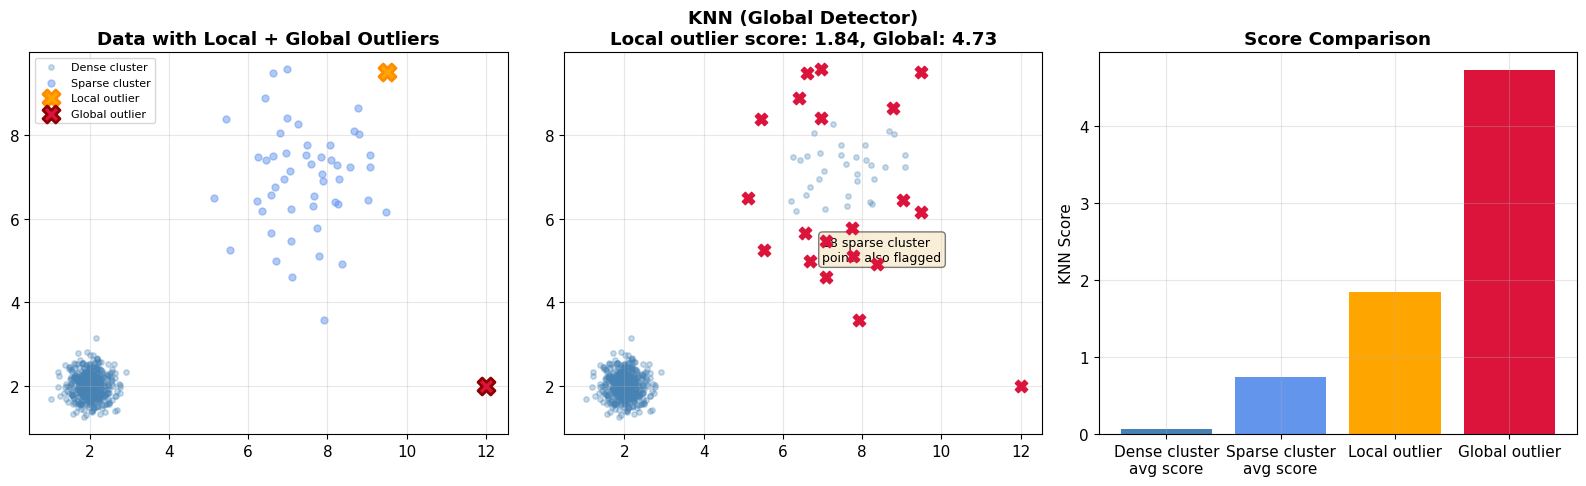

In [12]:
# Demonstrate local vs global outlier detection
np.random.seed(42)

# Dense cluster + sparse cluster + outliers
dense = np.random.normal([2, 2], 0.3, (500, 2))
sparse = np.random.normal([7, 7], 1.2, (50, 2))
# Local outlier: slightly outside sparse cluster
local_outlier = np.array([[9.5, 9.5]])
# Global outlier: far from everything
global_outlier = np.array([[12, 2]])

X_lg = np.vstack([dense, sparse, local_outlier, global_outlier])

# KNN (global detector)
tree = BallTree(X_lg)
dist, _ = tree.query(X_lg, k=10)
knn_scores = np.array([x.mean() for x in dist])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Data
ax = axes[0]
ax.scatter(dense[:, 0], dense[:, 1], alpha=0.3, s=15, c='steelblue', label='Dense cluster')
ax.scatter(sparse[:, 0], sparse[:, 1], alpha=0.5, s=25, c='cornflowerblue', label='Sparse cluster')
ax.scatter(*local_outlier[0], c='orange', s=150, marker='X', linewidth=2,
           edgecolors='darkorange', zorder=5, label='Local outlier')
ax.scatter(*global_outlier[0], c='crimson', s=150, marker='X', linewidth=2,
           edgecolors='darkred', zorder=5, label='Global outlier')
ax.set_title('Data with Local + Global Outliers', fontweight='bold')
ax.legend(fontsize=8)

# KNN scores
ax = axes[1]
top_n = 20
cutoff = np.sort(knn_scores)[-top_n]
flagged = knn_scores >= cutoff
ax.scatter(X_lg[~flagged, 0], X_lg[~flagged, 1], alpha=0.3, s=15, c='steelblue')
ax.scatter(X_lg[flagged, 0], X_lg[flagged, 1], c='crimson', s=80, marker='X', zorder=5)
# Annotate the outliers
local_score = knn_scores[-2]
global_score = knn_scores[-1]
ax.set_title(f'KNN (Global Detector)\nLocal outlier score: {local_score:.2f}, Global: {global_score:.2f}', fontweight='bold')

# Compare: many sparse cluster points also flagged
n_sparse_flagged = flagged[500:550].sum()
ax.annotate(f'{n_sparse_flagged} sparse cluster\npoints also flagged', xy=(7, 5), fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Explanation
ax = axes[2]
ax.bar(['Dense cluster\navg score', 'Sparse cluster\navg score', 'Local outlier', 'Global outlier'],
       [knn_scores[:500].mean(), knn_scores[500:550].mean(), local_score, global_score],
       color=['steelblue', 'cornflowerblue', 'orange', 'crimson'])
ax.set_ylabel('KNN Score')
ax.set_title('Score Comparison', fontweight='bold')

plt.tight_layout()
print(f"KNN scores (global detector):")
print(f"  Dense cluster avg: {knn_scores[:500].mean():.3f}")
print(f"  Sparse cluster avg: {knn_scores[500:550].mean():.3f}")
print(f"  Local outlier: {local_score:.3f}")
print(f"  Global outlier: {global_score:.3f}")
print(f"  Sparse cluster points in top-20: {n_sparse_flagged}")

This demonstrates the critical distinction between local and global outlier detection.

The global KNN detector assigns the **global outlier** (far from everything) the highest score -- correctly. But notice: **many normal members of the sparse cluster** also receive high scores, simply because the sparse cluster has inherently larger inter-point distances. The KNN detector does not know these are normal for their cluster -- it uses a single global standard.

The **local outlier** near the sparse cluster scores moderately -- higher than sparse cluster members, but possibly lower than some of them. A **local detector** like LOF (covered in later chapters) would handle this better by comparing each point's density to its *neighbors'* densities. The local outlier would score high because it is in an even sparser area than the already-sparse cluster around it.

**In practice, the choice matters:**
- Use **global detectors** (KNN, KDE, FPOF) when you want the most anomalous records overall
- Use **local detectors** (LOF, cluster-based with per-cluster normalization) when your data has clusters of different densities
- Use **both** in an ensemble (Chapter 12) for the most comprehensive detection

### 3.3.4 Scores vs. Binary Flags

Most modern detectors produce **continuous scores** that can be thresholded into binary labels. Scores are strictly more informative: they provide a ranked ordering and allow flexible threshold selection. Binary-only detectors (like basic DBSCAN) lose this ranking information.

Figure 3.8: Score distributions -- no clear cutoff (FPOF) vs. clearer cutoff (KDE).
  FPOF: smooth distribution, no natural threshold
  KDE: exponential tail, possible cutoff around 6


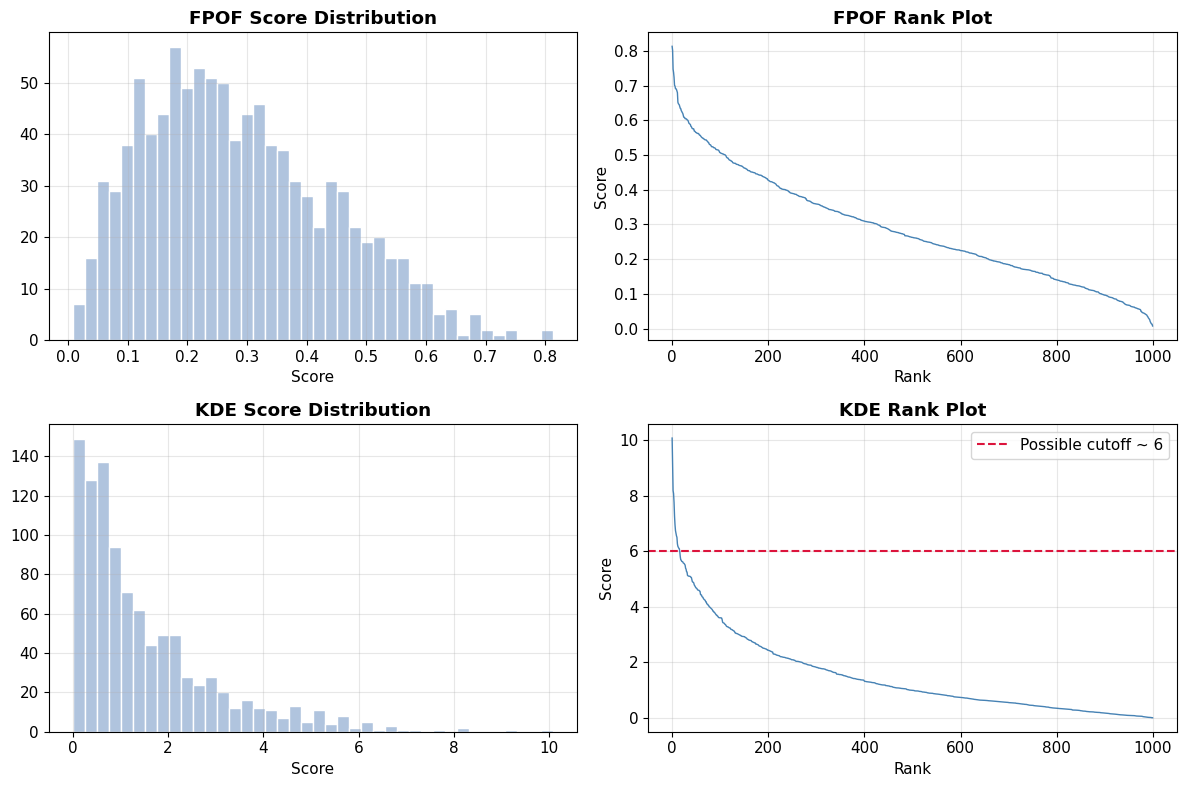

In [13]:
# Show why continuous scores are more useful than binary flags
np.random.seed(42)

# FPOF-like score distribution (roughly normal, no clear cutoff)
fpof_scores = np.random.beta(2, 5, 1000)

# KDE-like score distribution (exponential tail, clearer cutoff)
kde_scores = np.random.exponential(1.5, 1000)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# FPOF histograms and rank plots
ax = axes[0, 0]
ax.hist(fpof_scores, bins=40, color='lightsteelblue', edgecolor='white')
ax.set_title('FPOF Score Distribution', fontweight='bold')
ax.set_xlabel('Score')

ax = axes[0, 1]
ax.plot(range(len(fpof_scores)), sorted(fpof_scores, reverse=True), 'steelblue', linewidth=1)
ax.set_title('FPOF Rank Plot', fontweight='bold')
ax.set_xlabel('Rank'); ax.set_ylabel('Score')

# KDE histograms and rank plots
ax = axes[1, 0]
ax.hist(kde_scores, bins=40, color='lightsteelblue', edgecolor='white')
ax.set_title('KDE Score Distribution', fontweight='bold')
ax.set_xlabel('Score')

ax = axes[1, 1]
ax.plot(range(len(kde_scores)), sorted(kde_scores, reverse=True), 'steelblue', linewidth=1)
ax.axhline(6, color='crimson', linestyle='--', label='Possible cutoff ~ 6')
ax.set_title('KDE Rank Plot', fontweight='bold')
ax.set_xlabel('Rank'); ax.set_ylabel('Score')
ax.legend()

plt.tight_layout()

print("Figure 3.8: Score distributions -- no clear cutoff (FPOF) vs. clearer cutoff (KDE).")
print(f"  FPOF: smooth distribution, no natural threshold")
print(f"  KDE: exponential tail, possible cutoff around 6")

This recreates the book's Figure 3.8, illustrating a common practical dilemma.

**FPOF scores** (top row) follow a roughly normal distribution with no clear separation between inliers and outliers. The rank plot is a smooth curve with no "elbow." Setting a threshold here is inherently arbitrary -- any choice will include some normal points or exclude some mild outliers.

**KDE scores** (bottom row) show an exponential-like distribution with a long tail. The rank plot reveals a steeper region around score $\approx 6$, suggesting a more natural cutoff. But even here, the separation is not absolute.

In most contexts, only a manageable number of outliers will actually be investigated, so the practical approach is to take the **top $N$ scores** rather than trying to find a "correct" threshold. Continuous scores make this straightforward; binary flags do not.

### 3.3.5 Computational Considerations

Training time and inference time can vary dramatically:
- **KNN/Radius**: Training = building a BallTree, $O(n \log n)$. Inference = querying, $O(n \log n)$ per batch
- **DBSCAN**: $O(n \log n)$ with a spatial index, but $O(n^2)$ worst case
- **KDE**: $O(n^2)$ naive, $O(n \log n)$ with tree-based implementations
- **FPOF**: FIS mining can be expensive with many features or low min_support
- **Cluster-based (at inference)**: Very fast -- just compute distance to $k$ cluster centers

For real-time environments, cluster-based methods are often the most practical because inference requires only a small number of distance computations.

In [14]:
# Summary comparison of algorithm properties
summary = pd.DataFrame({
    'Algorithm': ['KNN/kthNN', 'Radius', 'KDE', 'DBSCAN', 'FPOF', 'Real vs Fake'],
    'Category': ['Distance', 'Density', 'Density', 'Cluster', 'Freq. Item Set', 'Model'],
    'Data Type': ['Numeric', 'Numeric', 'Numeric', 'Numeric', 'Categorical', 'Numeric'],
    'Local/Global': ['Global', 'Global', 'Global', 'Both', 'Global', 'Global'],
    'Output': ['Score', 'Score', 'Score', 'Label (+score)', 'Score', 'Label (+score)'],
    'Curse of Dim.': ['Vulnerable', 'Vulnerable', 'Vulnerable', 'Vulnerable', 'Moderate', 'Robust'],
    'Key Parameter': ['k', 'radius', 'bandwidth', 'eps, min_samples', 'min_support', 'classifier params'],
    'Interpretability': ['Medium', 'Medium', 'Low', 'Medium', 'High', 'High (with trees)']
})

print("Algorithm Comparison Summary:")
print(summary.to_string(index=False))

Algorithm Comparison Summary:
   Algorithm       Category   Data Type Local/Global         Output Curse of Dim.     Key Parameter  Interpretability
   KNN/kthNN       Distance     Numeric       Global          Score    Vulnerable                 k            Medium
      Radius        Density     Numeric       Global          Score    Vulnerable            radius            Medium
         KDE        Density     Numeric       Global          Score    Vulnerable         bandwidth               Low
      DBSCAN        Cluster     Numeric         Both Label (+score)    Vulnerable  eps, min_samples            Medium
        FPOF Freq. Item Set Categorical       Global          Score      Moderate       min_support              High
Real vs Fake          Model     Numeric       Global Label (+score)        Robust classifier params High (with trees)


This summary table captures the key distinctions between the algorithm families covered in this chapter. A few patterns stand out:

**Most algorithms are vulnerable to the curse of dimensionality** because they rely on distance calculations (Euclidean distance concentration). The exceptions are FPOF (which works with discrete item sets, not distances) and model-based approaches (which can use tree-based classifiers that are naturally resistant to irrelevant features).

**Most algorithms assume numeric data.** FPOF is the notable exception, designed for categorical features. In practice, most datasets have a mix, requiring encoding or binning.

**Interpretability varies widely.** FPOF and Real vs. Fake (with decision trees) can explain *why* a record was flagged. KDE provides density estimates but no direct explanation. KNN provides distances but not which features drive them.

## 3.4 Chapter Summary

This chapter introduced the machine learning approach to outlier detection -- multivariate methods that consider all features simultaneously, enabling detection of subtle anomalies that univariate methods cannot find.

**The curse of dimensionality** is the defining challenge:
- **Data sparsity**: with $20$ categorical features ($4$ values each), the space has $4^{20} > 10^{12}$ combinations -- every row is unique
- **Margin concentration**: with $20$ features, $\sim 88\%$ of points are on the margin of the data space
- **Distance concentration**: in high dimensions, all pairwise distances converge, making distance-based methods unreliable
- Mitigation strategies include **feature selection**, **dimensionality reduction** (PCA), and using **subsets of features** (Chapter 10)

**Algorithm categories:**
- **Distance-based** (KNN, kthNN): flag points far from their neighbors. Simple, effective, but vulnerable to dimensionality
- **Density-based** (Radius, KDE, LOF): flag points in low-density regions. KDE provides continuous density estimates; LOF adds local context
- **Cluster-based** (DBSCAN, HDBSCAN): flag points not fitting into any cluster. Efficient at inference; requires good clustering
- **Frequent item set-based** (FPOF): flag categorical records lacking common patterns. Interpretable; one of the few categorical-native methods
- **Model-based** (Real vs. Fake): train a classifier to distinguish real from synthetic data. Highly flexible; interpretable with tree-based classifiers

**Detector properties to consider:**
- Local vs. global: does the detector compare against a local or global standard of normality?
- Scores vs. labels: continuous scores are strictly more informative
- Scalability: training time, inference time, and feature count all matter
- Interpretability: can you explain *why* a record was flagged?
- Parameter sensitivity: some detectors (KNN) are sensitive; others (Isolation Forest, Chapter 5) are robust

In the next chapters, we explore specific algorithms in depth, starting with **Isolation Forest** (Chapter 5) -- one of the most popular and practically useful outlier detectors, notable for its speed, scalability, and robustness to high dimensions.

## Appendix: OpenML Dataset Examples (Run on Google Colab)

The following cells reproduce the book's exact examples using OpenML datasets.

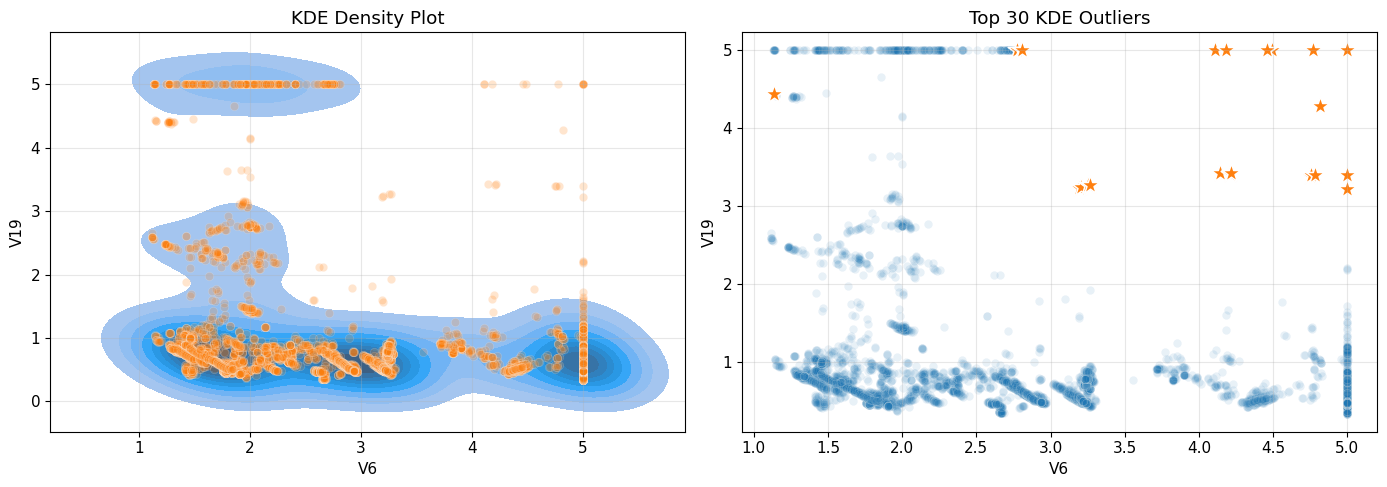

In [15]:
# Run on Google Colab -- Listing 3.3/3.4: KDE on wall-robot-navigation
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt
import seaborn as sns

data = fetch_openml('wall-robot-navigation', version=1, parser='auto')
data_df = pd.DataFrame(data.data, columns=data.feature_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
ax = axes[0]
sns.kdeplot(data=data_df, x="V6", y="V19", fill=True, ax=ax)
sns.scatterplot(data=data_df, x="V6", y="V19", alpha=0.2, ax=ax)
ax.set_title('KDE Density Plot')

# KDE outlier detection
X = data_df[['V6', 'V19']]
kde = KernelDensity(kernel='gaussian').fit(X)
log_density = kde.score_samples(X)
data_df['KDE Scores'] = -log_density
cutoff = sorted(data_df['KDE Scores'])[-30]
data_df['Outlier'] = data_df['KDE Scores'] > cutoff

ax = axes[1]
sns.scatterplot(data=data_df[data_df['Outlier']==False], x="V6", y="V19", alpha=0.1, ax=ax)
sns.scatterplot(data=data_df[data_df['Outlier']==True], x="V6", y="V19",
                s=200, alpha=1.0, marker="*", ax=ax)
ax.set_title('Top 30 KDE Outliers')
plt.tight_layout()
plt.show()

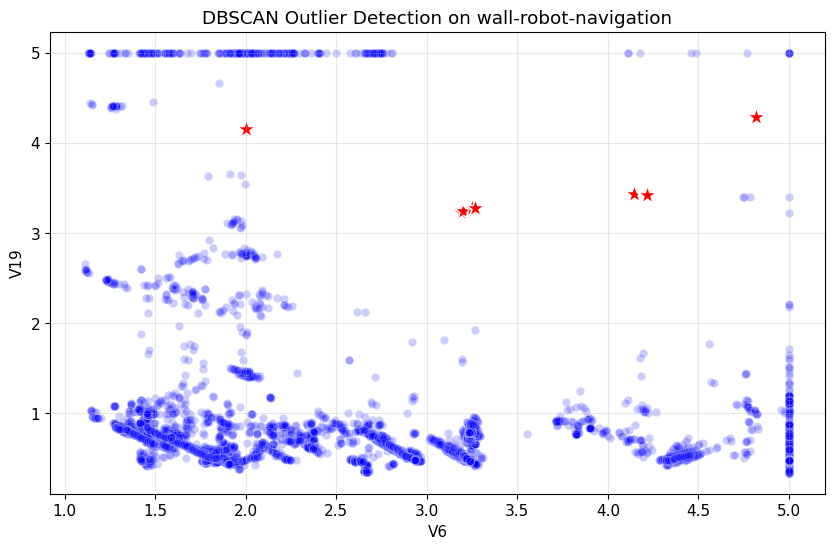

In [16]:
# Run on Google Colab -- Listing 3.5: DBSCAN on wall-robot-navigation
from sklearn.cluster import DBSCAN
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns

data = fetch_openml('wall-robot-navigation', version=1, parser='auto')
data_df = pd.DataFrame(data.data, columns=data.feature_names)
X = data_df[['V6', 'V19']]

clustering = DBSCAN().fit_predict(X)
data_df['DBScan Outliers'] = np.where(clustering < 0, 1, 0)

sns.scatterplot(data=data_df[data_df['DBScan Outliers']==False], x="V6", y="V19", alpha=0.2, color='blue')
sns.scatterplot(data=data_df[data_df['DBScan Outliers']==True], x="V6", y="V19",
                marker='*', s=200, color='red')
plt.title('DBSCAN Outlier Detection on wall-robot-navigation')
plt.show()

In [17]:
# Run on Google Colab -- Listing 3.6: FPOF on SpeedDating
# pip install mlxtend
from mlxtend.frequent_patterns import apriori
import pandas as pd
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)

data = fetch_openml('SpeedDating', version=1, parser='auto')
data_df = pd.DataFrame(data.data, columns=data.feature_names)
data_df = data_df[['d_pref_o_attractive', 'd_pref_o_sincere',
                    'd_pref_o_intelligence', 'd_pref_o_funny',
                    'd_pref_o_ambitious', 'd_pref_o_shared_interests']]
data_df = pd.get_dummies(data_df)
data_df = data_df.replace(1, True).replace(0, False)

frequent_itemsets = apriori(data_df, min_support=0.3, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

data_df['FPOF_Score'] = 0
for fis_idx in frequent_itemsets.index:
    fis = frequent_itemsets.loc[fis_idx, 'itemsets']
    support = frequent_itemsets.loc[fis_idx, 'support']
    col_list = list(fis)
    cond = True
    for col_name in col_list:
        cond = cond & (data_df[col_name])
    data_df.loc[data_df[cond].index, 'FPOF_Score'] += support

min_score = data_df['FPOF_Score'].min()
max_score = data_df['FPOF_Score'].max()
data_df['FPOF_Score'] = [(max_score - x) / (max_score - min_score) for x in data_df['FPOF_Score']]

print(f"Frequent item sets found: {len(frequent_itemsets)}")
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

Frequent item sets found: 24
     support                                           itemsets  length
8   0.797326                        (d_pref_o_ambitious_[0-15])       1
9   0.726307                 (d_pref_o_shared_interests_[0-15])       1
22  0.593817  (d_pref_o_ambitious_[0-15], d_pref_o_shared_in...       2
4   0.509907                    (d_pref_o_intelligence_[16-20])       1
7   0.461924                           (d_pref_o_funny_[16-20])       1
3   0.455956                         (d_pref_o_sincere_[16-20])       1
6   0.380520                            (d_pref_o_funny_[0-15])       1
2   0.365839                          (d_pref_o_sincere_[0-15])       1
1   0.359274                     (d_pref_o_attractive_[21-100])       1
10  0.347577  (d_pref_o_ambitious_[0-15], d_pref_o_attractiv...       2
